In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
!pip install -q datasets PyYAML scikit-learn

In [3]:
from pathlib import Path

import torch


PROJECT_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1"
)

REPO_ROOT = Path(
    "/content/drive/MyDrive/ATML/PA1-repo"
)

TASK2_WORK_ROOT = (
    PROJECT_ROOT / "task2"
)

TASK3_WORK_ROOT = (
    PROJECT_ROOT / "task3"
)

TASK3_REPO_ROOT = (
    REPO_ROOT / "task3"
)

PACS_ROOT = (
    PROJECT_ROOT / "datasets/PACS"
)

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type != "cuda":
    raise RuntimeError(
        "Change the Colab runtime to GPU."
    )

print(
    "GPU:",
    torch.cuda.get_device_name(0),
)

Device: cuda
GPU: Tesla T4


In [4]:
%cd /content/drive/MyDrive/ATML/PA1-repo

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import yaml

from datasets import load_from_disk

from sklearn.linear_model import (
    LogisticRegression,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
)

from sklearn.model_selection import (
    train_test_split,
)

from sklearn.preprocessing import (
    StandardScaler,
)

from common.seed import set_seed

from shared.pacs_protocol import (
    load_pacs_protocol,
)

from task2.models.classifier_head import (
    PACSClassifier,
)

from task3.data.source_loaders import (
    build_task3_source_datasets,
    build_task3_source_loaders,
)


SEED = 6304

set_seed(SEED)

print("Seed:", SEED)

/content/drive/MyDrive/ATML/PA1-repo
Seed: 6304


In [5]:
pacs_dataset = load_from_disk(
    str(PACS_ROOT)
)

PACS_SPLIT_PATH = (
    REPO_ROOT
    / "shared/splits/"
    "pacs_sketch_seed6304.json"
)

pacs_protocol = load_pacs_protocol(
    PACS_SPLIT_PATH
)

source_datasets = (
    build_task3_source_datasets(
        dataset=pacs_dataset,
        protocol=pacs_protocol,
    )
)

source_loaders = (
    build_task3_source_loaders(
        datasets=source_datasets,
        source_batch_size=8,
        evaluation_batch_size=64,
        number_of_workers=0,
        seed=SEED,
    )
)

print(
    "Source validation domains:",
    list(
        source_loaders[
            "source_validation"
        ].keys()
    ),
)

print(
    "Reserved target domain:",
    pacs_protocol[
        "target_domain"
    ],
)

print(
    "Target loader created:",
    "target_adaptation"
    in source_loaders,
)

Source validation domains: ['photo', 'art_painting', 'cartoon']
Reserved target domain: sketch
Target loader created: False


In [6]:
CHECKPOINT_PATHS = {
    "erm": (
        TASK2_WORK_ROOT
        / "checkpoints/source_only_best.pt"
    ),
    "dan_dg": (
        TASK3_WORK_ROOT
        / "checkpoints/dan_dg_best.pt"
    ),
    "sam": (
        TASK3_WORK_ROOT
        / "checkpoints/sam_best.pt"
    ),
}

for method_name, checkpoint_path in (
    CHECKPOINT_PATHS.items()
):
    print(
        method_name,
        "| exists:",
        checkpoint_path.exists(),
        "|",
        checkpoint_path,
    )

    if not checkpoint_path.exists():
        raise FileNotFoundError(
            checkpoint_path
        )

erm | exists: True | /content/drive/MyDrive/ATML/PA1/task2/checkpoints/source_only_best.pt
dan_dg | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/dan_dg_best.pt
sam | exists: True | /content/drive/MyDrive/ATML/PA1/task3/checkpoints/sam_best.pt


In [7]:
models = {}
checkpoint_metadata = {}

for method_name, checkpoint_path in (
    CHECKPOINT_PATHS.items()
):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=DEVICE,
        weights_only=False,
    )

    model = PACSClassifier(
        number_of_classes=7
    ).to(DEVICE)

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    models[method_name] = model

    checkpoint_metadata[
        method_name
    ] = {
        "selected_epoch": int(
            checkpoint["epoch"]
        ),
        "selection_score": float(
            checkpoint[
                "selection_score"
            ]
        ),
    }

    print(
        method_name,
        "| epoch:",
        checkpoint["epoch"],
        "| source macro-F1:",
        checkpoint[
            "selection_score"
        ],
    )

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


erm | epoch: 12 | source macro-F1: 0.9366743407680399
dan_dg | epoch: 1 | source macro-F1: 0.05066996495567924
sam | epoch: 11 | source macro-F1: 0.9515140737316559


In [8]:
source_domains = [
    "photo",
    "art_painting",
    "cartoon",
]

domain_to_label = {
    domain_name: domain_index
    for domain_index, domain_name
    in enumerate(source_domains)
}

minimum_domain_size = min(
    len(
        source_datasets[
            "source_validation"
        ][domain_name]
    )
    for domain_name in source_domains
)

random_generator = (
    np.random.default_rng(SEED)
)

balanced_positions = {}

for domain_name in source_domains:
    domain_size = len(
        source_datasets[
            "source_validation"
        ][domain_name]
    )

    selected_positions = (
        random_generator.choice(
            domain_size,
            size=minimum_domain_size,
            replace=False,
        )
    )

    balanced_positions[
        domain_name
    ] = np.sort(
        selected_positions
    )

print(
    "Samples retained per domain:",
    minimum_domain_size,
)


def extract_balanced_features(
    model,
):
    feature_blocks = []
    class_label_blocks = []
    domain_label_blocks = []

    model.eval()

    with torch.inference_mode():
        for domain_name in source_domains:
            domain_features = []
            domain_class_labels = []

            data_loader = (
                source_loaders[
                    "source_validation"
                ][domain_name]
            )

            for batch in data_loader:
                images = batch[
                    "image"
                ].to(DEVICE)

                class_labels = batch[
                    "label"
                ]

                _, features = model(
                    images,
                    return_features=True,
                )

                domain_features.append(
                    features.cpu()
                )

                domain_class_labels.append(
                    class_labels.cpu()
                )

            domain_features = torch.cat(
                domain_features,
                dim=0,
            ).numpy()

            domain_class_labels = (
                torch.cat(
                    domain_class_labels,
                    dim=0,
                ).numpy()
            )

            selected_positions = (
                balanced_positions[
                    domain_name
                ]
            )

            selected_features = (
                domain_features[
                    selected_positions
                ]
            )

            selected_class_labels = (
                domain_class_labels[
                    selected_positions
                ]
            )

            selected_domain_labels = (
                np.full(
                    minimum_domain_size,
                    domain_to_label[
                        domain_name
                    ],
                    dtype=np.int64,
                )
            )

            feature_blocks.append(
                selected_features
            )

            class_label_blocks.append(
                selected_class_labels
            )

            domain_label_blocks.append(
                selected_domain_labels
            )

    return {
        "features": np.concatenate(
            feature_blocks,
            axis=0,
        ),
        "class_labels": np.concatenate(
            class_label_blocks,
            axis=0,
        ),
        "domain_labels": np.concatenate(
            domain_label_blocks,
            axis=0,
        ),
    }


feature_sets = {}

for method_name, model in (
    models.items()
):
    print(
        "Extracting features:",
        method_name,
    )

    feature_sets[
        method_name
    ] = extract_balanced_features(
        model
    )

    print(
        "Feature shape:",
        feature_sets[
            method_name
        ]["features"].shape,
    )

Samples retained per domain: 334
Extracting features: erm
Feature shape: (1002, 512)
Extracting features: dan_dg
Feature shape: (1002, 512)
Extracting features: sam
Feature shape: (1002, 512)


In [9]:
reference_domain_labels = (
    feature_sets["erm"][
        "domain_labels"
    ]
)

all_indices = np.arange(
    len(reference_domain_labels)
)

train_indices, test_indices = (
    train_test_split(
        all_indices,
        test_size=0.30,
        random_state=SEED,
        stratify=reference_domain_labels,
    )
)

separability_rows = []
domain_confusion_matrices = {}

for method_name, feature_data in (
    feature_sets.items()
):
    features = feature_data[
        "features"
    ]

    domain_labels = feature_data[
        "domain_labels"
    ]

    scaler = StandardScaler()

    training_features = (
        scaler.fit_transform(
            features[
                train_indices
            ]
        )
    )

    testing_features = (
        scaler.transform(
            features[
                test_indices
            ]
        )
    )

    classifier = LogisticRegression(
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        random_state=SEED,
    )

    classifier.fit(
        training_features,
        domain_labels[
            train_indices
        ],
    )

    predictions = classifier.predict(
        testing_features
    )

    domain_accuracy = accuracy_score(
        domain_labels[
            test_indices
        ],
        predictions,
    )

    domain_balanced_accuracy = (
        balanced_accuracy_score(
            domain_labels[
                test_indices
            ],
            predictions,
        )
    )

    domain_confusion_matrices[
        method_name
    ] = confusion_matrix(
        domain_labels[
            test_indices
        ],
        predictions,
        labels=[0, 1, 2],
    )

    separability_rows.append(
        {
            "method": method_name,
            "domain_accuracy": (
                domain_accuracy
            ),
            "domain_balanced_accuracy": (
                domain_balanced_accuracy
            ),
            "chance_accuracy": 1.0 / 3.0,
            "samples_per_domain": (
                minimum_domain_size
            ),
            "diagnostic_train_samples": (
                len(train_indices)
            ),
            "diagnostic_test_samples": (
                len(test_indices)
            ),
            "logistic_regression_C": 1.0,
            "split_seed": SEED,
        }
    )

domain_separability = pd.DataFrame(
    separability_rows
)

separability_path = (
    TASK3_REPO_ROOT
    / "results/"
    "source_domain_separability.csv"
)

domain_separability.to_csv(
    separability_path,
    index=False,
)

print(
    domain_separability.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    separability_path,
)

method  domain_accuracy  domain_balanced_accuracy  chance_accuracy  samples_per_domain  diagnostic_train_samples  diagnostic_test_samples  logistic_regression_C  split_seed
   erm         0.883721                  0.883465         0.333333                 334                       701                      301                    1.0        6304
dan_dg         0.498339                  0.498020         0.333333                 334                       701                      301                    1.0        6304
   sam         0.877076                  0.876799         0.333333                 334                       701                      301                    1.0        6304

Saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/source_domain_separability.csv


In [10]:
SHARPNESS_BATCH_PER_DOMAIN = 32
SHARPNESS_RADIUS = 0.05

sharpness_generator = (
    np.random.default_rng(SEED)
)

sharpness_images = []
sharpness_labels = []
sharpness_domains = []

for domain_name in source_domains:
    domain_dataset = (
        source_datasets[
            "source_validation"
        ][domain_name]
    )

    selected_positions = (
        sharpness_generator.choice(
            len(domain_dataset),
            size=(
                SHARPNESS_BATCH_PER_DOMAIN
            ),
            replace=False,
        )
    )

    for position in selected_positions:
        sample = domain_dataset[
            int(position)
        ]

        sharpness_images.append(
            sample["image"]
        )

        sharpness_labels.append(
            int(sample["label"])
        )

        sharpness_domains.append(
            domain_name
        )

sharpness_images = torch.stack(
    sharpness_images
).to(DEVICE)

sharpness_labels = torch.tensor(
    sharpness_labels,
    dtype=torch.long,
    device=DEVICE,
)

print(
    "Sharpness batch shape:",
    tuple(
        sharpness_images.shape
    ),
)

print(
    "Samples per domain:",
    {
        domain_name: (
            sharpness_domains.count(
                domain_name
            )
        )
        for domain_name
        in source_domains
    },
)

print(
    "Perturbation radius:",
    SHARPNESS_RADIUS,
)

Sharpness batch shape: (96, 3, 224, 224)
Samples per domain: {'photo': 32, 'art_painting': 32, 'cartoon': 32}
Perturbation radius: 0.05


In [11]:
def calculate_sharpness_proxy(
    model,
    images,
    labels,
    radius,
):
    model.eval()
    model.zero_grad(
        set_to_none=True
    )

    original_logits = model(
        images
    )

    original_loss = F.cross_entropy(
        original_logits,
        labels,
    )

    original_loss.backward()

    trainable_parameters = [
        parameter
        for parameter in model.parameters()
        if (
            parameter.requires_grad
            and parameter.grad is not None
        )
    ]

    squared_gradient_norm = sum(
        parameter.grad.detach()
        .pow(2)
        .sum()
        for parameter
        in trainable_parameters
    )

    gradient_norm = (
        squared_gradient_norm
        .sqrt()
        .clamp_min(1e-12)
    )

    perturbations = []

    with torch.no_grad():
        for parameter in (
            trainable_parameters
        ):
            perturbation = (
                float(radius)
                * parameter.grad
                / gradient_norm
            )

            parameter.add_(
                perturbation
            )

            perturbations.append(
                (
                    parameter,
                    perturbation,
                )
            )

    try:
        with torch.inference_mode():
            perturbed_logits = model(
                images
            )

            perturbed_loss = (
                F.cross_entropy(
                    perturbed_logits,
                    labels,
                )
            )

    finally:
        with torch.no_grad():
            for (
                parameter,
                perturbation,
            ) in perturbations:
                parameter.sub_(
                    perturbation
                )

    sharpness_delta = (
        perturbed_loss
        - original_loss.detach()
    )

    original_accuracy = (
        (
            original_logits.argmax(
                dim=1
            )
            == labels
        )
        .float()
        .mean()
    )

    model.zero_grad(
        set_to_none=True
    )

    return {
        "original_loss": float(
            original_loss.detach().item()
        ),
        "perturbed_loss": float(
            perturbed_loss.item()
        ),
        "sharpness_delta": float(
            sharpness_delta.item()
        ),
        "gradient_norm": float(
            gradient_norm.item()
        ),
        "original_accuracy": float(
            original_accuracy.item()
        ),
    }


sharpness_rows = []

for method_name, model in (
    models.items()
):
    sharpness_result = (
        calculate_sharpness_proxy(
            model=model,
            images=sharpness_images,
            labels=sharpness_labels,
            radius=SHARPNESS_RADIUS,
        )
    )

    sharpness_rows.append(
        {
            "method": method_name,
            "radius": (
                SHARPNESS_RADIUS
            ),
            "original_loss": (
                sharpness_result[
                    "original_loss"
                ]
            ),
            "perturbed_loss": (
                sharpness_result[
                    "perturbed_loss"
                ]
            ),
            "sharpness_delta": (
                sharpness_result[
                    "sharpness_delta"
                ]
            ),
            "gradient_norm": (
                sharpness_result[
                    "gradient_norm"
                ]
            ),
            "original_accuracy": (
                sharpness_result[
                    "original_accuracy"
                ]
            ),
            "samples_per_domain": (
                SHARPNESS_BATCH_PER_DOMAIN
            ),
            "total_samples": (
                len(sharpness_labels)
            ),
            "batch_seed": SEED,
        }
    )

sharpness_results = pd.DataFrame(
    sharpness_rows
)

sharpness_path = (
    TASK3_REPO_ROOT
    / "results/"
    "source_sharpness_proxy.csv"
)

sharpness_results.to_csv(
    sharpness_path,
    index=False,
)

print(
    sharpness_results.to_string(
        index=False
    )
)

print()
print(
    "Saved to:",
    sharpness_path,
)

method  radius  original_loss  perturbed_loss  sharpness_delta  gradient_norm  original_accuracy  samples_per_domain  total_samples  batch_seed
   erm    0.05       0.168335        0.646060         0.477725       7.379429           0.947917                  32             96        6304
dan_dg    0.05       1.941604        2.003554         0.061950       0.789166           0.218750                  32             96        6304
   sam    0.05       0.174613        0.313839         0.139226       2.474850           0.947917                  32             96        6304

Saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/results/source_sharpness_proxy.csv


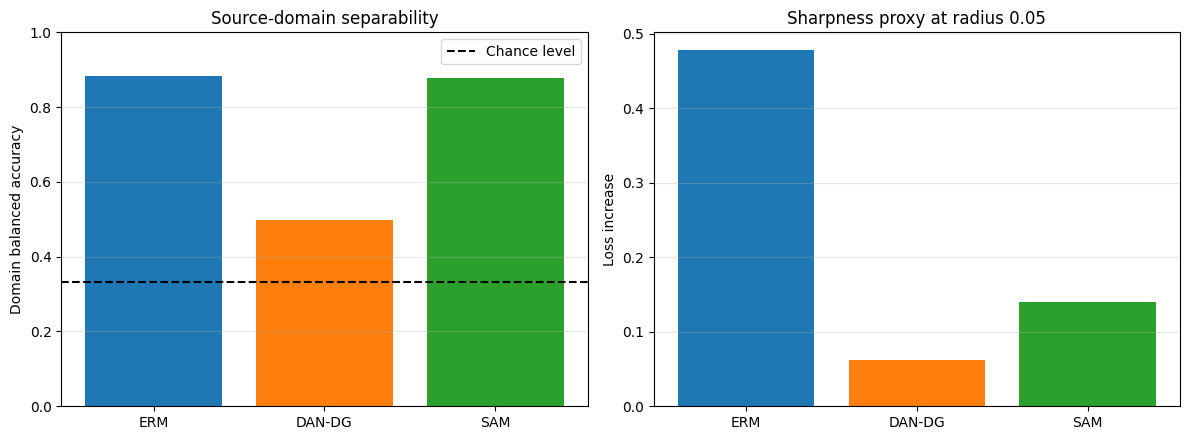

Figure saved to: /content/drive/MyDrive/ATML/PA1-repo/task3/figures/source_diagnostics.png


In [12]:
method_order = [
    "erm",
    "dan_dg",
    "sam",
]

display_names = {
    "erm": "ERM",
    "dan_dg": "DAN-DG",
    "sam": "SAM",
}

separability_plot = (
    domain_separability
    .set_index("method")
    .loc[method_order]
)

sharpness_plot = (
    sharpness_results
    .set_index("method")
    .loc[method_order]
)

figure, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5),
)

axes[0].bar(
    [
        display_names[
            method_name
        ]
        for method_name
        in method_order
    ],
    separability_plot[
        "domain_balanced_accuracy"
    ],
    color=[
        "tab:blue",
        "tab:orange",
        "tab:green",
    ],
)

axes[0].axhline(
    1.0 / 3.0,
    color="black",
    linestyle="--",
    label="Chance level",
)

axes[0].set_ylim(0.0, 1.0)
axes[0].set_ylabel(
    "Domain balanced accuracy"
)
axes[0].set_title(
    "Source-domain separability"
)
axes[0].grid(
    axis="y",
    alpha=0.3,
)
axes[0].legend()

axes[1].bar(
    [
        display_names[
            method_name
        ]
        for method_name
        in method_order
    ],
    sharpness_plot[
        "sharpness_delta"
    ],
    color=[
        "tab:blue",
        "tab:orange",
        "tab:green",
    ],
)

axes[1].set_ylabel(
    "Loss increase"
)
axes[1].set_title(
    "Sharpness proxy at radius 0.05"
)
axes[1].grid(
    axis="y",
    alpha=0.3,
)

figure.tight_layout()

figure_path = (
    TASK3_REPO_ROOT
    / "figures/"
    "source_diagnostics.png"
)

figure_path.parent.mkdir(
    parents=True,
    exist_ok=True,
)

figure.savefig(
    figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print(
    "Figure saved to:",
    figure_path,
)

In [13]:
diagnostic_metadata = {
    "seed": SEED,
    "methods": method_order,
    "target_images_loaded": False,
    "target_labels_used": False,
    "domain_separability": {
        "source_domains": (
            source_domains
        ),
        "samples_per_domain": int(
            minimum_domain_size
        ),
        "split": "70/30 stratified",
        "split_seed": SEED,
        "classifier": (
            "multinomial logistic regression"
        ),
        "classifier_C": 1.0,
        "chance_accuracy": (
            1.0 / 3.0
        ),
        "results": [
            {
                "method": row[
                    "method"
                ],
                "domain_accuracy": float(
                    row[
                        "domain_accuracy"
                    ]
                ),
                "domain_balanced_accuracy": float(
                    row[
                        "domain_balanced_accuracy"
                    ]
                ),
            }
            for _, row
            in domain_separability.iterrows()
        ],
    },
    "sharpness_proxy": {
        "radius": (
            SHARPNESS_RADIUS
        ),
        "samples_per_domain": (
            SHARPNESS_BATCH_PER_DOMAIN
        ),
        "total_samples": int(
            len(sharpness_labels)
        ),
        "batch_seed": SEED,
        "model_mode": "evaluation",
        "perturbation": (
            "one normalized gradient-ascent step"
        ),
        "results": [
            {
                "method": row[
                    "method"
                ],
                "original_loss": float(
                    row[
                        "original_loss"
                    ]
                ),
                "perturbed_loss": float(
                    row[
                        "perturbed_loss"
                    ]
                ),
                "sharpness_delta": float(
                    row[
                        "sharpness_delta"
                    ]
                ),
                "gradient_norm": float(
                    row[
                        "gradient_norm"
                    ]
                ),
            }
            for _, row
            in sharpness_results.iterrows()
        ],
    },
    "selected_checkpoints": (
        checkpoint_metadata
    ),
}

metadata_path = (
    TASK3_REPO_ROOT
    / "results/"
    "source_diagnostics_metadata.json"
)

with metadata_path.open(
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        diagnostic_metadata,
        metadata_file,
        indent=2,
    )

print(
    json.dumps(
        diagnostic_metadata,
        indent=2,
    )
)

{
  "seed": 6304,
  "methods": [
    "erm",
    "dan_dg",
    "sam"
  ],
  "target_images_loaded": false,
  "target_labels_used": false,
  "domain_separability": {
    "source_domains": [
      "photo",
      "art_painting",
      "cartoon"
    ],
    "samples_per_domain": 334,
    "split": "70/30 stratified",
    "split_seed": 6304,
    "classifier": "multinomial logistic regression",
    "classifier_C": 1.0,
    "chance_accuracy": 0.3333333333333333,
    "results": [
      {
        "method": "erm",
        "domain_accuracy": 0.8837209302325582,
        "domain_balanced_accuracy": 0.8834653465346535
      },
      {
        "method": "dan_dg",
        "domain_accuracy": 0.4983388704318937,
        "domain_balanced_accuracy": 0.498019801980198
      },
      {
        "method": "sam",
        "domain_accuracy": 0.8770764119601329,
        "domain_balanced_accuracy": 0.8767986798679868
      }
    ]
  },
  "sharpness_proxy": {
    "radius": 0.05,
    "samples_per_domain": 32,
    "tota